In [1]:
#Load all libraries
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.callbacks import ReduceLROnPlateau


def load_dataset(csv_path, hmi_folder_path):
    # Load the dataframe
    df = pd.read_csv(csv_path)

    # Convert image paths into full paths
    hmi_folder_path = Path(hmi_folder_path)
    hmi_paths = df["HMI_img"].apply(lambda x: hmi_folder_path / x)

    # Load all the .npy files into memory
    hmi_data = np.zeros((len(hmi_paths), 224, 224))
    for i, path in enumerate(hmi_paths):
        hmi_data[i] = np.load(path)

    return df, hmi_data


# Attach dataset in notebook → Kaggle mounts it here:
csv_path = "/kaggle/input/csc-480-680-project-1-2025-fall/train_df.csv"
hmi_folder_path = "/kaggle/input/csc-480-680-project-1-2025-fall/HMI_data/hmi_data/"

df, hmi_data = load_dataset(csv_path, hmi_folder_path)

# Build dataset
x_train = hmi_data
y_train = df[["tsi_pert_0"]].values

2025-12-04 22:53:00.658137: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764888780.851447      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764888780.908627      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
#Check all information in the training data 
print("=== Data Overview ===")
print(f"Number of samples: {len(df)}")


# Sample TSI values
print("\nSample tsi_pert_0 values:")
print(df["tsi_pert_0"].head())
print("\ntsi_pert_0 stats:")
print(df["tsi_pert_0"].describe())

# HMI image array info
print("\nHMI image array info:")
print(f"hmi_data shape: {hmi_data.shape}")
print(f"hmi_data dtype: {hmi_data.dtype}")
print(f"hmi_data min pixel value: {hmi_data.min()}")
print(f"hmi_data max pixel value: {hmi_data.max()}")
print("\nMissing values per column:")
print(df.isna().sum())


=== Data Overview ===
Number of samples: 3288

Sample tsi_pert_0 values:
0   -0.09160
1   -0.11470
2   -0.13780
3   -0.14385
4   -0.14990
Name: tsi_pert_0, dtype: float64

tsi_pert_0 stats:
count    3288.000000
mean       -0.039786
std         0.340318
min        -1.603713
25%        -0.290180
50%        -0.124762
75%         0.217667
max         0.914428
Name: tsi_pert_0, dtype: float64

HMI image array info:
hmi_data shape: (3288, 224, 224)
hmi_data dtype: float64
hmi_data min pixel value: 0.0
hmi_data max pixel value: 70865.1796875

Missing values per column:
index         0
tsi_pert_0    0
HMI_img       0
timestamp     0
dtype: int64


In [3]:
# Reproducibility 
tf.random.set_seed(42)
np.random.seed(42)

In [4]:
#Data Preprocessing 
img_min = hmi_data.min()
img_max = hmi_data.max()

print("Using global min/max:", img_min, img_max)

# train normalization to [0, 1]
img_min = hmi_data.min()
img_max = hmi_data.max()

x_train = (hmi_data - img_min) / (img_max - img_min)
x_train = x_train[..., np.newaxis].astype("float32")

y_train = df["tsi_pert_0"].values.astype("float32")

print("x_train shape:", x_train.shape)
print("x_train min/max:", x_train.min(), x_train.max())

Using global min/max: 0.0 70865.1796875
x_train shape: (3288, 224, 224, 1)
x_train min/max: 0.0 1.0


In [5]:
#CNN for Regression

from tensorflow.keras import layers, models, regularizers

input_shape = (224, 224, 1)

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=input_shape),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

     layers.Conv2D(512, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber(),
    metrics=["mae"]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1764888815.601927      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764888815.602506      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
# Compile Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.Huber(),
    metrics=["mae"])

early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
lr_sched = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
)

history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, lr_sched],
    verbose=1
)

Epoch 1/100


I0000 00:00:1764888819.982635      65 service.cc:148] XLA service 0x7cde38011c20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764888819.983475      65 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764888819.983498      65 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764888820.343101      65 cuda_dnn.cc:529] Loaded cuDNN version 90300


 3/83 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.1837 - mae: 0.3212

I0000 00:00:1764888826.305915      65 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - loss: 0.1124 - mae: 0.2843 - val_loss: 0.0740 - val_mae: 0.3697 - learning_rate: 5.0000e-04
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0638 - mae: 0.2834 - val_loss: 0.0623 - val_mae: 0.3460 - learning_rate: 5.0000e-04
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0616 - mae: 0.2833 - val_loss: 0.0620 - val_mae: 0.3470 - learning_rate: 5.0000e-04
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0611 - mae: 0.2833 - val_loss: 0.0617 - val_mae: 0.3468 - learning_rate: 5.0000e-04
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0610 - mae: 0.2833 - val_loss: 0.0617 - val_mae: 0.3468 - learning_rate: 5.0000e-04
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0609 - mae: 0.2834 - val_loss: 0.0617 - val_mae: 0.3469 - learning_rate: 5.0000e-04
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0609 - mae: 0.2834 - val_loss: 0.0615 - val_mae: 0.3463 - learning_rate:

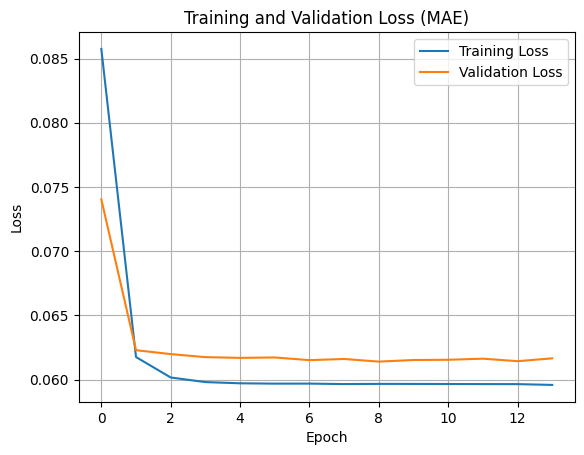

In [7]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss (MAE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
#Mean Absolute Error
best_val_mae = min(history.history["val_mae"])
print("Best validation MAE:", best_val_mae)


Best validation MAE: 0.3459959030151367


In [9]:
# ===== SUBMISSION =====
# test set
test_set = "/kaggle/input/csc-480-680-project-1-2025-fall/test_df.csv"
testdf, test_hmi_data = load_dataset(test_set, hmi_folder_path)

#Private test set
test_set_private = "/kaggle/input/csc-480-680-project-1-2025-fall/test_df_private.csv"
testdf_private, testprivate_hmi_data = load_dataset(test_set_private, hmi_folder_path)

submission_testing = pd.concat([testdf, testdf_private], ignore_index=True)

# Combine image arrays
x_testfinal = np.concatenate([test_hmi_data, testprivate_hmi_data], axis=0)
x_testfinal = (x_testfinal - img_min) / (img_max - img_min)
x_testfinal = x_testfinal[..., np.newaxis].astype("float32")

print("x_testfinal shape:", x_testfinal.shape)  # should be (549, 224, 224, 1)


x_testfinal shape: (549, 224, 224, 1)


In [10]:
# Make predictions ONCE
predictions = model.predict(x_testfinal).reshape(-1)

submission_testing['tsi_pert_0'] = predictions
submission_testing = submission_testing[["index", "tsi_pert_0"]]

print(submission_testing.head())
submission_testing.to_csv('submission.csv', index=False)
print("submission.csv created with shape:", submission_testing.shape)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
   index  tsi_pert_0
0      0    0.029523
1      1    0.029523
2      2    0.029523
3      3    0.029523
4      4    0.029523
submission.csv created with shape: (549, 2)
